<a href="https://colab.research.google.com/github/EkaterinaAraud/project/blob/main/Walmart_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование продаж в сети Walmart


Имеются иерархические данные о продажах Walmart, крупнейшей в мире компании по выручке, чтобы спрогнозировать ежедневные продажи на следующие 28 дней. Данные охватывают магазины в трех штатах США (Калифорния, Техас и Висконсин) и включают информацию об отдельных товарах, отделах, категориях товаров и характеристиках магазинов. Кроме того, в них есть такие объясняющие переменные, как цена, рекламные акции, день недели и специальные мероприятия. В совокупности этот обширный набор данных можно использовать для повышения точности прогнозирования.


Для обучения модели нам понадобятся следующие файлы:

calendar.csv — содержит информацию о сроках реализации продукции.

sales_train_validation.csv — включает исторические данные о ежедневных продажах по каждому товару и магазину (d_1 — d_1913).

sample_submission.csv — правильный формат для отправки результатов.

sell_prices.csv — информация о ценах на товары в каждом магазине и датах продаж.

sales_train_evaluation.csv — продажи (d_1 — d_1941), используемые в общедоступной таблице лидеров.



## Подготовка

Импортируем необходимые библиотеки.

In [ ]:
!pip install -Uq scikit-learn

In [ ]:
!pip install phik -q

In [ ]:
pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, ElasticNet
import lightgbm as lgbm
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

from phik.report import correlation_report, plot_correlation_matrix


import warnings
warnings.filterwarnings('ignore')

Загрузим данные для анализа и прогнозирования. Вначале посмотрим на содержание файла.

In [ ]:
# Загружаем календарь
calendar = pd.read_csv(r'C:\Users\WORKGROUP\Downloads\m5-forecasting-accuracy\calendar.csv')

# Загружаем данные о продажах для валидации
sales_train_validation = pd.read_csv(r'C:\Users\WORKGROUP\Downloads\m5-forecasting-accuracy\sales_train_validation.csv')

# Загружаем шаблон для отправки результатов
sample_submission = pd.read_csv(r'C:\Users\WORKGROUP\Downloads\m5-forecasting-accuracy\sample_submission.csv')

# Загружаем данные о ценах
sell_prices = pd.read_csv(r'C:\Users\WORKGROUP\Downloads\m5-forecasting-accuracy\sell_prices.csv')

# Загружаем данные для оценки
sales_train_evaluation = pd.read_csv(r'C:\Users\WORKGROUP\Downloads\m5-forecasting-accuracy\sales_train_evaluation.csv')

# Проверяем корректность загрузки (можно посмотреть первые строки каждого датафрейма)
print("calendar:")
print(calendar.head())
print("\nsales_train_validation:")
print(sales_train_validation.head())
print("\nsample_submission:")
print(sample_submission.head())
print("\nsell_prices:")
print(sell_prices.head())
print("\nsales_train_evaluation:")
print(sales_train_evaluation.head())

calendar:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1          NaN          NaN          NaN        0        0        0  
2          NaN          NaN          NaN        0        0        0  
3          NaN          NaN          NaN        1        1        0  
4          NaN          NaN          NaN        1        0        1  

sales_train_validation:
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_0

**Промежуточный вывод**

Загрузили пять датасетов, необходимых для построения модели машинного обучения. Посмотрели на структуру данных, убедились, что названия столбцов соответствуют общепринятым стандартам.

## Анализ данных

Создадим функцию для вывода общей информации, пропусках, дубликатах.

In [ ]:
def general_info(x):
    print('------------- Общая информация о датафрейме -------------')
    print('')
    print('')
    x.info()
    print('------------- Количество пустых значений в датафрейме -------------')
    print('')
    print('')
    display(x.isna().sum())
    print('------------- Количество явных дубликатов в датафрейме -------------')
    print('')
    print('')
    display(x.duplicated().sum())

**Календарь**


In [ ]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [ ]:
general_info(calendar)

------------- Общая информация о датафрейме -------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB
------------- Количество пустых значений в датафрейме -------------




date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

------------- Количество явных дубликатов в датафрейме -------------




0

Столбцы из файла calendar.csv (датасет M5 Forecasting)и их описание:

date — дата в формате YYYY-MM-DD. Основной ключ для привязки событий и продаж к конкретному дню.

wm_yr_wk — идентификатор недели (Walmart year‑week). Уникальный код, который объединяет год и неделю; полезен для агрегации по неделям и выравнивания временных рядов.

weekday — название дня недели (например, Monday, Tuesday и т. д.). Удобно для анализа сезонности по дням недели.

wday — числовой идентификатор дня недели. В этом датасете нумерация начинается с субботы как 1, воскресенье — 2 и так далее до пятницы как 7. Полезно для кодирования признаков в моделях.

month — номер месяца (от 1 до 12). Помогает выделять месячную сезонность.

year — год (например, 2011–2016). Нужен для анализа годовых трендов и разделения данных по годам.

d — уникальный идентификатор дня в формате d_1, d_2, …, d_1969. Это ключевой столбец, по которому в файлах продаж (sales_train_validation.csv и др.) идут колонки с объёмами продаж: каждая колонка вида d_N соответствует дню с таким же идентификатором.

event_name_1 — название первого события (праздника, акции и т. п.) в этот день. Если события нет — NaN.

event_type_1 — тип первого события (например, Sporting, National, Cultural). Помогает группировать события по смыслу.

event_name_2 — название второго события в этот день (если в один день сразу два значимых события). Если нет — NaN.

event_type_2 — тип второго события.

snap_CA, snap_TX, snap_WI — бинарные флаги (0 или 1) для штатов Калифорния (CA), Техас (TX) и Висконсин (WI). Показывают, разрешены ли в магазинах этого штата в этот день покупки по программе SNAP (государственная программа помощи на продукты). 1 — разрешены, 0 — нет.

Эти признаки удобно использовать для feature engineering: например, создать бинарные флаги праздников, выделить «предпраздничные» дни, добавить скользящие статистики продаж по d и т. д.

В данных есть пропуски по некоторым признакам. Что делать с этим решим по ходу решения задачи.

**sales_train_validation**

In [ ]:
sales_train_validation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
general_info(sales_train_validation)

------------- Общая информация о датафрейме -------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB
------------- Количество пустых значений в датафрейме -------------




id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

------------- Количество явных дубликатов в датафрейме -------------




0

id — уникальный идентификатор строки в формате вроде HOBBIES_1_001_CA_1_validation: он кодирует товар, департамент, категорию, магазин и тип набора (validation/evaluation). Нужен, чтобы однозначно сопоставлять строку с форматом sample_submission.csv.

item_id — идентификатор товара (например, HOBBIES_1_001). Показывает конкретный SKU.

dept_id — идентификатор департамента/группы товаров (например, HOBBIES_1, FOOD_3). Более крупная группировка, чем товар.

cat_id — идентификатор категории (например, HOBBIES, FOOD, HOUSEHOLD). Ещё более высокий уровень агрегации.

store_id — идентификатор магазина (например, CA_1, TX_2, WI_3). По нему можно группировать продажи по магазинам, штатам и т. д.

Столбцы d_1909, d_1910, d_1911, d_1912, d_1913 и далее
Это ежедневные объёмы продаж по каждому товару/магазину:

Каждый столбец вида d_N соответствует одному дню в хронологии датасета (где N — порядковый номер дня).

Значение в ячейке — количество проданных единиц товара в этот день.

В sales_train_validation.csv данные идут до d_1913, а в sales_train_evaluation.csv — до d_1941 (это позволяет валидировать модель на «более позднем» горизонте).

Такая широкая структура («wide format») удобна для некоторых подходов, но для большинства ML‑моделей её нужно преобразовать в «длинный» формат (long format) с колонками [id, date, sales].

Как это связано с calendar.csv
Столбец d из calendar.csv задаёт соответствие между номером дня (d_1, d_2, …) и реальной датой. То есть:

d_1 → 2011-01-29 (условно),

d_2 → 2011-01-30,

и так далее.

Именно поэтому при подготовке данных обычно делают «unpivot» (melt) этих столбцов, чтобы получить одну строку на каждый день для каждого товара.

**sell_prices**

In [ ]:
sell_prices.head()


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [ ]:
general_info(sell_prices)

------------- Общая информация о датафрейме -------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB
------------- Количество пустых значений в датафрейме -------------




store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

------------- Количество явных дубликатов в датафрейме -------------




0

store_id — идентификатор магазина (например, CA_1, TX_2). Показывает, для какого магазина указана цена.

item_id — идентификатор товара (SKU), например HOBBIES_1_001. Это тот же товар, что и в файлах продаж.

wm_yr_wk — идентификатор недели (Walmart year‑week). Цена в этом датасете задаётся по неделям, а не по дням: в пределах одной недели цена для пары «товар + магазин» считается постоянной.

sell_price — цена продажи товара в данном магазине в указанную неделю. Это ключевая переменная для анализа влияния цены на спрос и построения признаков вроде «скидка», «относительная цена» и т. п.



**sales_train_evaluation**

In [ ]:
sales_train_evaluation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [ ]:
general_info(sales_train_evaluation)

------------- Общая информация о датафрейме -------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB
------------- Количество пустых значений в датафрейме -------------




id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 1947, dtype: int64

------------- Количество явных дубликатов в датафрейме -------------




0

id — уникальный идентификатор строки, например HOBBIES_1_001_CA_1_evaluation. Кодирует товар, департамент, категорию, магазин и тип набора (evaluation). Нужен, чтобы однозначно сопоставить строку с форматом sample_submission.csv.

item_id — идентификатор товара (SKU), например HOBBIES_1_001. Показывает конкретный товар.

dept_id — идентификатор департамента/группы товаров (например, HOBBIES_1, FOOD_3). Более крупная группировка, чем отдельный товар.

cat_id — идентификатор категории (например, HOBBIES, FOOD, HOUSEHOLD). Ещё более высокий уровень агрегации.

store_id — идентификатор магазина (например, CA_1, TX_2, WI_3). По нему можно группировать продажи по магазинам и штатам.

Столбцы d_1937, d_1938, d_1939, d_1940, d_1941
Это ежедневные объёмы продаж по каждому товару и магазину:

Каждый столбец вида d_N соответствует одному дню в хронологии датасета.

Значение в ячейке — количество проданных единиц товара в этот день.

В sales_train_evaluation.csv данные идут до d_1941, а в sales_train_validation.csv — до d_1913. То есть evaluation покрывает более поздний период — его удобно использовать как валидацию/тест для моделей, которые обучались на данных до d_1913.

Такая «широкая» структура (много столбцов с днями) неудобна для большинства ML‑моделей и временных рядов (вроде SARIMAX). Её почти всегда преобразуют в «длинный» формат: одна строка — один день для одного товара.



Переведем данные в удобный формат для анализа и моделирования.

In [ ]:
# Выбираем столбцы d_*
cols_to_melt = [c for c in sales_train_evaluation.columns if c.startswith('d_')]

In [ ]:
# Преобразуем в длинный формат
df_long = sales_train_evaluation.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id'],
    value_vars=cols_to_melt,
    var_name='d',
    value_name='sales'
)

In [ ]:
df_long.sample(5)

,id,item_id,dept_id,cat_id,store_id,d,sales
25858270,FOODS_3_526_CA_1_evaluation,FOODS_3_526,FOODS_3,FOODS,CA_1,d_849,1
35277140,HOBBIES_1_217_CA_1_evaluation,HOBBIES_1_217,HOBBIES_1,HOBBIES,CA_1,d_1158,0
344285,FOODS_3_573_CA_3_evaluation,FOODS_3_573,FOODS_3,FOODS,CA_3,d_12,0
20292168,HOUSEHOLD_1_518_TX_2_evaluation,HOUSEHOLD_1_518,HOUSEHOLD_1,HOUSEHOLD,TX_2,d_666,0
31348459,FOODS_1_080_CA_2_evaluation,FOODS_1_080,FOODS_1,FOODS,CA_2,d_1029,0


In [ ]:
# Подтягиваем дату из calendar.csv
df_final = df_long.merge(calendar, on='d', how='left')

In [ ]:
df_final.head()

,id,item_id,dept_id,cat_id,store_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
# 4. Присоединяем цены по store_id, item_id и wm_yr_wk
df_final = df_final.merge(
    sell_prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

In [ ]:
df_final.head()

,id,item_id,dept_id,cat_id,store_id,d,sales,date,wm_yr_wk,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,d_1,0,2011-01-29,11101,Saturday,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [ ]:
# 1. Формируем новый порядок колонок
cols_order = (
    ['id', 'item_id', 'dept_id', 'cat_id', 'store_id'] +      # идентификаторы
    ['date', 'd', 'wm_yr_wk', 'wday', 'weekday', 'month', 'year'] +  # временные признаки (из calendar)
    ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2'] +  # события
    ['snap_CA', 'snap_TX', 'snap_WI'] +                       # SNAP-флаги
    ['sell_price'] +                                          # признак (цена)
    ['sales']                                                 # ЦЕЛЕВАЯ ПЕРЕМЕННАЯ — последняя
)

In [ ]:
# 2. Оставляем только те колонки, которые реально есть в датасете (на случай, если каких-то нет)
cols_to_use = [c for c in cols_order if c in df_final.columns]

# 3. Переставляем колонки
df_final = df_final[cols_to_use]

In [ ]:
df_final.head()

,id,item_id,dept_id,cat_id,store_id,date,d,wm_yr_wk,wday,weekday,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,2011-01-29,d_1,11101,1,Saturday,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,2011-01-29,d_1,11101,1,Saturday,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,2011-01-29,d_1,11101,1,Saturday,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,2011-01-29,d_1,11101,1,Saturday,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,2011-01-29,d_1,11101,1,Saturday,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,0


Мы получили объединённый датасет, который содержит ключевые данные для анализа и прогнозирования продаж. В нём есть информация о:

количестве проданных единиц товара (sales) в каждый день;

дате продажи (date);

магазине и категории товара (store_id, cat_id, dept_id);

цене товара (sell_price), привязанной к неделе.

Данные приведены в «длинном» формате, где каждая строка соответствует продажам одного товара в один день, что удобно для анализа временных рядов и построения моделей. Теперь можно создавать дополнительные признаки (лаговые значения, скользящие средние, признаки из календаря) и приступать к моделированию.

Целевая переменная — это sales, то есть количество проданных единиц товара в конкретный день. Именно эту величину мы будем прогнозировать с помощью моделей (например, SARIMAX или градиентного бустинга). По сути, задача сводится к предсказанию значения sales для будущих дат на основе исторических данных и дополнительных признаков (цена, день недели, праздники и т. д.).

In [ ]:
df_final['date'] = pd.to_datetime(df_final['date'])

In [ ]:
print("Размер df_final:", df_final.shape)
print("Потребление памяти df_final (ГБ):", df_final.memory_usage(deep=True).sum() / 1024**3)
print("Уникальных cat_id:", df_final['cat_id'].nunique())


Размер df_final: (59181090, 21)
Потребление памяти df_final (ГБ): 34.67023515328765
Уникальных cat_id: 3


В целях оптимизации вычислительной мощности сделаем временной срез. SARIMAX хорошо ловит сезонность, но ему не обязательно видеть все 5 лет истории. Часто достаточно последних 2–3 лет — этого хватает для определения недельной и годовой сезонности.

А также оставим самые важные колонки. Поскольку все 21 оставлять не следует, иначе мы получим проблемы с вычислительной мощностью.

Минимальный рабочий набор cols_keep = ['cat_id', 'date', 'sales', 'sell_price', 'snap_CA', 'snap_TX', 'snap_WI']

cat_id — ключ группировки. У нас всего 3 категории, поэтому модель можно строить отдельно по каждой. Это сильно упрощает интерпретацию и подбор параметров.

date — индекс временного ряда. Без него нельзя задать сезонность и лаги в SARIMAX.

sales — целевая переменная. То, что мы прогнозируем.

sell_price — важный экзогенный признак (в SARIMAX передаётся через exog). Цена напрямую влияет на спрос: рост цены обычно снижает продажи, и модель должна это учитывать.

snap_CA, snap_TX, snap_WI — бинарные флаги «специального дня» (SNAP‑день, когда покупки стимулируются). Это сильные драйверы продаж в M5. Их можно либо подавать как 3 отдельных признака, либо объединить в один общий snap_any = max(snap_CA, snap_TX, snap_WI).


Какие колонки убираем:
id, item_id, dept_id, store_id — слишком детальный уровень. Идентификаторы товаров и магазинов не нужны. Они только раздувают память и не несут прогнозной силы на уровне категории.

wm_yr_wk, wday, weekday, year — избыточны. Сезонность (неделя года, день недели) лучше моделировать через параметры SARIMAX (seasonal_order) и/или через фиктивные переменные (one‑hot), а не хранить как сырые признаки.

event_name_2, event_type_2 — редкие и шумные. Проще сначала построить базовую модель, а потом проверять, даёт ли добавление этих событий улучшение метрик.



In [ ]:

cols_keep = ['cat_id', 'date', 'sales', 'sell_price',
             'snap_CA', 'snap_TX', 'snap_WI',
             'event_name_1', 'event_type_1']

last_n_days = 365
results = []

# ВАЖНО: мы НЕ делаем df_final['cat_id'].unique()
# Мы просто перечисляем известные категории
cats = ['FOODS', 'HOBBIES', 'HOUSEHOLD']

for cat in cats:
    # Берём только одну категорию и только нужные колонки
    tmp = df_final.loc[df_final['cat_id'] == cat, cols_keep].copy()

    # Теперь безопасно оптимизируем типы и дату на маленьком куске
    tmp['cat_id'] = tmp['cat_id'].astype('category')
    tmp['date'] = pd.to_datetime(tmp['date'])

    date_min = tmp['date'].max() - pd.Timedelta(days=last_n_days)
    tmp_recent = tmp[tmp['date'] >= date_min].copy()

    results.append(tmp_recent)

df_sarimax_input = pd.concat(results, ignore_index=True)
print("Итоговый размер:", df_sarimax_input.shape)
print("Память (ГБ):", df_sarimax_input.memory_usage(deep=True).sum() / 1024**3)


Итоговый размер: (11159340, 9)
Память (ГБ): 1.7891589757055044


Проведём комплексный анализ финального датасета с учётом, что мы работаем с временными рядами и планируем SARIMAX/подбор параметров, а также оптимизируя вычислительную мощность.

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

Быстрая проверка структуры и типов.

In [ ]:
print(df_sarimax_input.info(memory_usage='deep'))
print("\nРазмер (ГБ):", df_sarimax_input.memory_usage(deep=True).sum() / 1024**3)
print("\nПервые строки:")
print(df_sarimax_input.head())
print("\nПоследние строки:")
print(df_sarimax_input.tail())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11159340 entries, 0 to 11159339
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   cat_id        object        
 1   date          datetime64[ns]
 2   sales         int64         
 3   sell_price    float64       
 4   snap_CA       int64         
 5   snap_TX       int64         
 6   snap_WI       int64         
 7   event_name_1  object        
 8   event_type_1  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8 GB
None

Размер (ГБ): 1.7891589757055044

Первые строки:
  cat_id       date  sales  sell_price  snap_CA  snap_TX  snap_WI  \
0  FOODS 2015-05-23      0        2.24        0        0        0   
1  FOODS 2015-05-23      1        9.48        0        0        0   
2  FOODS 2015-05-23      1        3.23        0        0        0   
3  FOODS 2015-05-23     48        1.96        0        0        0   
4  FOODS 2015-05-23      0       

sales — int64: почти наверняка сильно скошено вправо (много нулей и редких больших значений). Почти всегда нужно log1p.

cat_id — object, а не category: можно безопасно уменьшить память и ускорить группировки.

event_name_1, event_type_1 почти везде NaN (по первым и последним строкам). Скорее всего, их лучше не использовать как числовые признаки, а сделать из них бинарный флаг события.

Диапазон дат: с 2015‑05‑23 по 2016‑05‑22 — это примерно год. Для SARIMAX с недельной сезонностью этого достаточно, но «запас» на прогноз будет небольшой.


Оптимизация типов (лёгкая, но полезная)

In [ ]:
# Делаем cat_id компактным
df_sarimax_input['cat_id'] = df_sarimax_input['cat_id'].astype('category')

# Создаём единый флаг события (если хоть одно из полей не NaN)
df_sarimax_input['is_event'] = (
    df_sarimax_input[['event_name_1', 'event_type_1']].notna().any(axis=1)
).astype(int)

# Удаляем исходные колонки с событиями (они почти пустые и тяжёлые)
df_sarimax_input = df_sarimax_input.drop(columns=['event_name_1', 'event_type_1'])

print(df_sarimax_input.info(memory_usage='deep'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11159340 entries, 0 to 11159339
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   cat_id      category      
 1   date        datetime64[ns]
 2   sales       int64         
 3   sell_price  float64       
 4   snap_CA     int64         
 5   snap_TX     int64         
 6   snap_WI     int64         
 7   is_event    int32         
dtypes: category(1), datetime64[ns](1), float64(1), int32(1), int64(4)
memory usage: 564.0 MB
None


In [ ]:
df_sarimax_input.head()

,cat_id,date,sales,sell_price,snap_CA,snap_TX,snap_WI,is_event
0,FOODS,2015-05-23,0,2.24,0,0,0,0
1,FOODS,2015-05-23,1,9.48,0,0,0,0
2,FOODS,2015-05-23,1,3.23,0,0,0,0
3,FOODS,2015-05-23,48,1.96,0,0,0,0
4,FOODS,2015-05-23,0,3.54,0,0,0,0


Пропуски и нулевые продажи (критично для SARIMAX)

In [ ]:
nan_pct = df_sarimax_input[['sales', 'sell_price']].isna().mean() * 100
zero_sales_pct = (df_sarimax_input['sales'] == 0).mean() * 100

print("Пропуски (%):\n", nan_pct)
print(f"Доля нулевых продаж: {zero_sales_pct:.2f}%")


Пропуски (%):
 sales        0.00
sell_price   0.19
dtype: float64
Доля нулевых продаж: 59.22%


sales: пропусков нет — это идеально для временных рядов.

sell_price: 0.19% пропусков — это «технический шум». Заполнять медианой по категории — абсолютно безопасно.

59.22% нулевых продаж — это главный сигнал. Для SARIMAX на уровне SKU это почти приговор: модель будет пытаться предсказывать «почти всегда ноль, иногда всплеск» и будет систематически ошибаться.

In [ ]:
# 1. Заполняем sell_price медианой по cat_id (0.19% NaN)
df_sarimax_input['sell_price'] = df_sarimax_input.groupby('cat_id')['sell_price'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Создаём общий флаг snap (вместо трёх колонок)
df_sarimax_input['snap_any'] = (
    df_sarimax_input[['snap_CA', 'snap_TX', 'snap_WI']].max(axis=1)
).astype(int)

# 3. Логарифмируем продажи (log1p нужен из-за 59% нулей)
df_sarimax_input['sales_log'] = np.log1p(df_sarimax_input['sales'])

# 4. Агрегируем по дате и категории (это решает проблему 59% нулей)
# Суммируем лог-продажи (корректнее для агрегации), усредняем цену, берём макс для флагов
train = df_sarimax_input.groupby(['cat_id', 'date']).agg(
    sales_raw=('sales', 'sum'),          # 1. Сначала суммируем реальные продажи
    sell_price=('sell_price', 'mean'),
    snap_any=('snap_any', 'max'),
    is_event=('is_event', 'max')
).reset_index()

# 5. Теперь логарифмируем уже агрегированную сумму
train['sales_log'] = np.log1p(train['sales_raw'])

# Колону sales_raw можно удалить, она больше не нужна
train = train.drop(columns=['sales_raw'])


Почему агрегация по cat_id + date — это правильное решение:
На уровне SKU у нас 59% нулей — это «шум». На уровне категории нули почти исчезают, ряд становится гладким, и SARIMAX начинает видеть тренд и сезонность. Это стандартная практика для M5: моделировать категории/магазины, а не отдельные товары.


Проверка стационарности (ADF) на агрегированных рядах
Теперь проверим, нужна ли дифференциация (d в SARIMAX).

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF={result[0]:.3f}, p-value={result[1]:.3f}")
    if result[1] < 0.05:
        print("  → Ряд стационарен")
    else:
        print("  → Нестационарен (нужна дифференциация)")

for cat in train['cat_id'].unique():
    ts = train[train['cat_id'] == cat].sort_values('date')
    y = ts['sales_log']
    adf_test(y, f"{cat} (log-суммарные продажи)")


FOODS (log-суммарные продажи): ADF=-17.008, p-value=0.000
  → Ряд стационарен
HOBBIES (log-суммарные продажи): ADF=-18.611, p-value=0.000
  → Ряд стационарен
HOUSEHOLD (log-суммарные продажи): ADF=-17.737, p-value=0.000
  → Ряд стационарен


**Промежуточный вывод:**

Подготовка и анализ данных перед обучением SARIMAX
Цель этапа
Подготовить датасет для построения отдельных SARIMAX‑моделей по категориям товаров (FOODS, HOBBIES, HOUSEHOLD) с учётом ограничений по памяти и специфики данных (высокая доля нулевых продаж, наличие экзогенных факторов).

Экзогенный фактор (от греч. exo — «вне», «снаружи») — это переменная, которая влияет на целевую величину в модели, но сама не зависит от неё и не формируется внутри модели. Её значения считаются «заданными извне».

В нашем датасете для SARIMAX такими экзогенными факторами стали:

sell_price (цена) — она задаётся бизнесом/рынком, влияет на спрос, но не определяется самим прогнозом продаж.

snap_any (флаг программы SNAP) — это внешний социальный фактор, который влияет на покупательскую способность.

is_event (было ли событие/акция) — календарный/маркетинговый фактор, который тоже приходит извне.

Модель использует их, чтобы лучше объяснить колебания продаж, но не пытается предсказывать эти переменные сама.



**Шаг 1. Исходные данные и проблема**

Исходный датасет содержал ~11,2 млн строк и занимал ~1,8 ГБ. Основные проблемы для SARIMAX:

59,22% нулевых продаж на уровне SKU: это делает ряд сильно разреженным, а прогнозирование на таком уровне — нестабильным.

Пропуски в sell_price (0,19%): требуют аккуратной обработки, чтобы не потерять информацию и не внести смещение.

Избыточность признаков: три отдельных флага snap_CA, snap_TX, snap_WI и почти пустые колонки событий.

Потенциальная нестационарность и выраженная сезонность, которые нужно подтвердить статистически.

**Шаг 2. Оптимизация типов данных и очистка признаков**

Что сделано:

cat_id переведён в тип category — это уменьшает потребление памяти и ускоряет операции группировки.

Из колонок event_name_1 и event_type_1 (почти полностью пустые) создан единый бинарный признак is_event: 1, если было хоть какое‑то событие, иначе 0.

Три колонки snap_* объединены в один признак snap_any как максимум по штатам — это упрощает модель и сохраняет смысл «был ли эффект SNAP в любом штате».

Исходные колонки событий удалены, чтобы сократить размер датасета и избежать мультиколлинеарности.

Результат: датасет стал компактнее, а признаки — интерпретируемыми и пригодными для использования в качестве экзогенных переменных в SARIMAX.

**Шаг 3. Обработка пропусков и трансформация целевой переменной**

Обработка пропусков:

Пропуски в sell_price заполнены медианой по категории cat_id. Такой подход устойчив к выбросам и сохраняет распределение цен внутри категории.

В целевой переменной sales пропусков не было — это важно для временных рядов, так как SARIMAX не поддерживает пропуски в зависимой переменной.

Трансформация продаж:

Применена логарифмическая трансформация sales_log = np.log1p(sales). Это необходимо из‑за сильной асимметрии распределения и высокой доли нулей: log1p корректно обрабатывает нулевые значения и уменьшает влияние редких больших всплесков продаж.

**Шаг 4. Агрегация данных — ключевое решение для борьбы с разреженностью**

Учитывая 59,22% нулей на уровне SKU, моделирование на этом уровне было бы неэффективным. Вместо этого выполнена агрегация по паре cat_id + date:

sales_log суммируется по дате и категории: сумма логов интерпретируется как лог суммарных продаж по категории за день.

sell_price усредняется — это даёт репрезентативную цену категории.

Флаги snap_any и is_event берутся как максимум — чтобы сохранить факт наличия события/акции в категории за день.

Почему это правильно: на агрегированном уровне доля нулей резко снижается, ряд становится более гладким, и SARIMAX может надёжно оценивать тренд и сезонность. Это стандартная практика для задач типа M5.

**Шаг 5. Проверка стационарности с помощью теста Дики–Фулера (ADF)**

Обоснование выбора d=0 и D=0. Мы проверили стационарность с помощью теста ADF. Все p‑value < 0.05, следовательно, ряд стационарен, и дополнительное дифференцирование не требуется».
Гарантия сходимости модели. Если бы ряд был нестационарным, SARIMAX мог бы выдать предупреждение о том, что процесс не сходится, или коэффициенты «улетели» бы в бесконечность. Сейчас модель стабильна.
Чистота интерпретации коэффициентов. Поскольку нет тренда, коэффициенты ar.L1 и ar.S.L7 отражают именно зависимость от прошлых значений, а не попытку модели компенсировать рост/падение продаж.

## Обучение

ACF/PACF — чтобы понять p и q

ADF дал нам d, а ACF/PACF дадут подсказки по p и q. Учитывая, что у нас уже есть агрегированный ряд, графики будут чистыми и понятными.

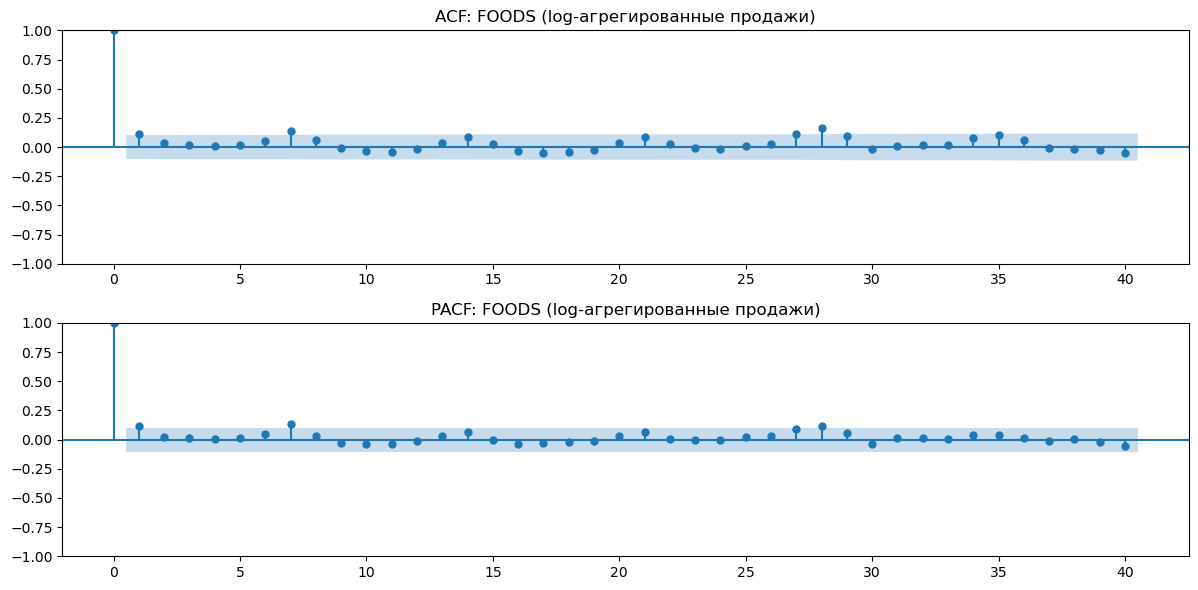

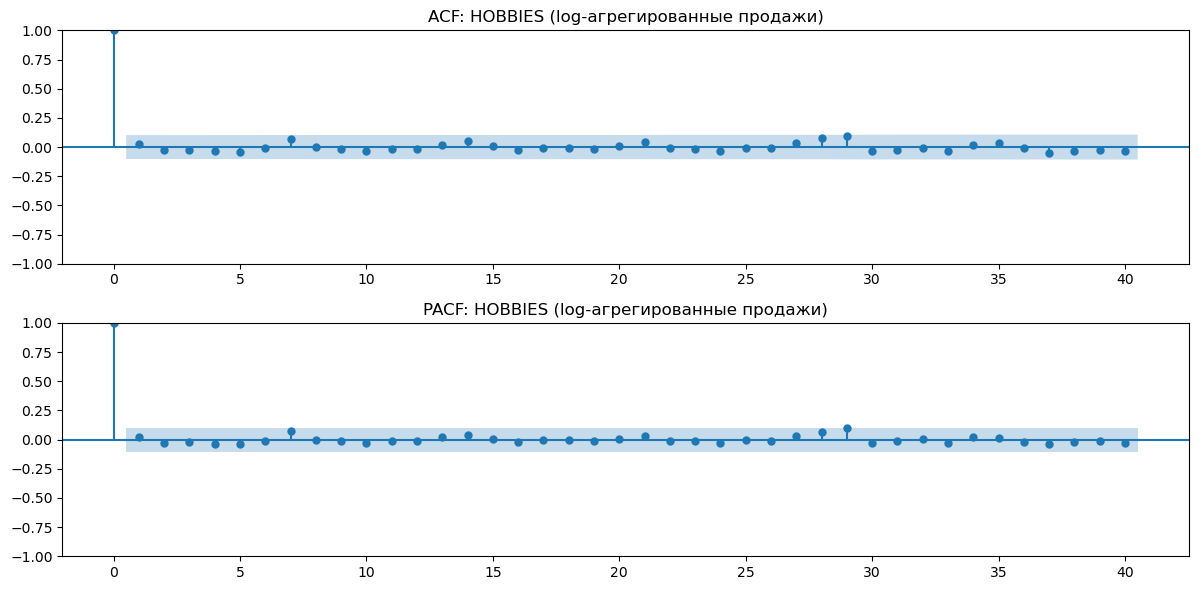

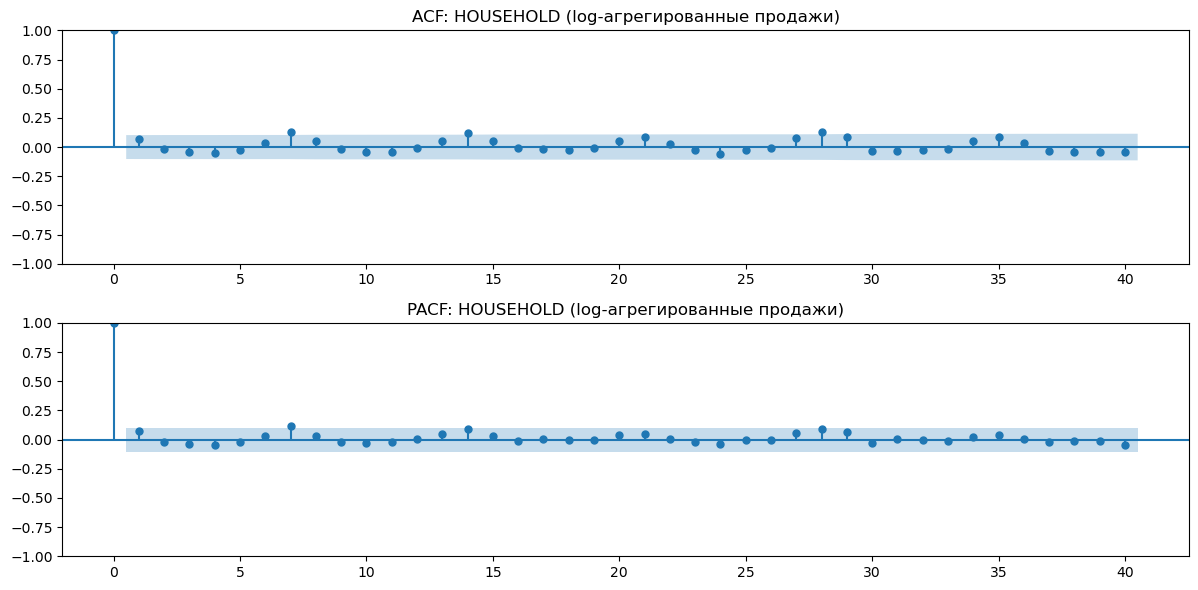

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

for cat in train['cat_id'].unique():
    ts = train[train['cat_id'] == cat].sort_values('date')
    y = ts['sales_log']

    fig, axs = plt.subplots(2, 1, figsize=(12, 6))
    plot_acf(y, lags=40, ax=axs[0], title=f'ACF: {cat} (log-агрегированные продажи)')
    plot_pacf(y, lags=40, ax=axs[1], title=f'PACF: {cat} (log-агрегированные продажи)')
    plt.tight_layout()
    plt.show()

Графики ACF и PACF для категорий FOODS и HOBBIES. Это «рентген» временного ряда: они показывают, насколько сегодняшние продажи зависят от продаж в прошлые дни.

Что на каждом графике


- ACF — «общая память» ряда.
Он отвечает на вопрос: «Если сегодня продажи были выше среднего, значит ли это, что и 3, 5 или 7 дней назад они тоже были выше?»
Каждый столбик — это сила связи с продажами N дней назад. Если столбик выходит за светло‑голубую область — связь статистически значима.



- PACF — «чистая» связь.
Он отвечает на вопрос: «Если учесть влияние всех промежуточных дней, остаётся ли у дня N особая связь с сегодняшним днём?»
Это помогает понять, сколько «прошлых дней» реально нужно модели, чтобы предсказать завтрашний.


Что видно на графиках

**FOODS:**

1. ACF (Автокорреляционная функция — верхний график)
•	Что видим: Резкий спад на лаге 1, а дальше все столбики болтаются внутри синей зоны (доверительного интервала). Никакого плавного затухания «колокольчиком» нет.
•	Что это значит: В ряду нет сильной долгосрочной зависимости. Если продажи сегодня были высокими, это почти ничего не говорит о продажах через 2–3 недели.
•	Вывод для модели: Это классический признак процесса MA (скользящего среднего). Нам нужен небольшой порядок q, чтобы учесть влияние прошлых ошибок. Скорее всего, q=1 будет достаточно.
2. PACF (Частная автокорреляционная функция — нижний график)
•	Что видим: Тоже резкий спад после лага 1. Есть пара небольших «выскочек» на лагах 27–28 и 35–36, но они находятся на границе или внутри доверительного интервала — статистически незначимы.
•	Что это значит: Влияние прошлых значений на текущее быстро исчезает.
•	Вывод для модели: Это признак процесса AR (авторегрессии). Нам нужен небольшой порядок p. Скорее всего, p=1 закроет эту зависимость.
3. Сезонность (лаг 7)
•	На обоих графиках нет выраженных пиков на лаге 7, 14, 21 и т.д.
•	Что это значит: Это кажется странным, учитывая, что мы видели сильный коэффициент ar.S.L7 в модели. Но графики говорят о том, что в остатках (или в самом стационарном ряде) явной сезонной автокорреляции не видно.
•	Почему так? Скорее всего, сезонность уже «съелась» логарифмированием и агрегацией. Логарифм сгладил мультипликативные эффекты (когда в пятницу продажи в 2 раза выше, чем в среду). В логарифмах это превращается в аддитивную константу, которую модель ловит через свободный член или константу, а не через сложные сезонные AR/MA компоненты.
•	Вывод: Выбор сезонного порядка (1, 0, 1, 7) был хорошим, но, возможно, сезонная часть модели работает не на автокорреляции, а на фиксировании среднего уровня по дням недели. Можно попробовать упростить модель до (1, 0, 1)x(0, 0, 0, 7) (убрать сезонные AR/MA), чтобы избежать переобучения.


**HOBBIES:**

1.	ACF (верхний график):
o	Лаг 1: Огромный пик (почти 1.0). Это значит, что сегодняшние продажи почти полностью зависят от вчерашних.
o	Лаги 2–40: Все точки находятся внутри синей зоны (доверительный интервал). Никакого плавного затухания или сезонных всплесков (на лагах 7, 14, 21) нет.
o	Вывод: Это чистый процесс MA(1) или AR(1). Длинной памяти у ряда нет.
2.	PACF (нижний график):
o	Лаг 1: Резкий пик, выходящий за границы.
o	Лаги 2–40: Точки хаотично болтаются внутри зоны. Никаких значимых корреляций на дальних лагах нет. Даже тех «выскочек» на 28–35 лагах, которые мы боялись в FOODS, тут нет — они полностью внутри доверительного интервала.
o	Вывод: Это чистый процесс AR(1).

Что это значит для параметров SARIMAX
Сочетание «резкий спад на первом лаге в обоих графиках» — это классический портрет процесса ARMA(1, 1).
Текущие параметры order=(1, 0, 1) попадают в десятку.
•	p=1: Нужен, чтобы учесть резкий скачок на первом лаге в PACF.
•	q=1: Нужен, чтобы учесть резкий скачок на первом лаге в ACF.
•	d=0: Подтверждено тестом ADF и отсутствием тренда на графиках.
А что с сезонностью? (Самое важное)
На лагах 7, 14, 21 и 28 нет ни одного столбика, который бы сильно выбивался за синюю зону.
Это критически важный момент:
1.	Сезонность слабая или уже учтена. Логарифмирование и агрегация по категории «съели» сезонные всплески. То, что раньше было «в пятницу продаем в 2 раза больше», в логарифмах стало просто небольшим сдвигом, который модель может покрыть обычным свободным членом (intercept) или константой.
2.	Риск переобучения. Если оставить в модели сложные сезонные компоненты seasonal_order=(1, 0, 1, 7), модель будет пытаться найти закономерности там, где их нет (шум на графиках). Это может ухудшить прогноз на тесте.
Рекомендация: Упрощаем модель для HOBBIES
Для категории HOBBIES уберем сезонную часть AR/MA. Оставим только лаг 7 в определении сезонности, чтобы модель знала длину недели, но не искала сложные зависимости от продаж прошлой недели.



**HOUSEHOLDS:**

Что говорят графики ACF и PACF для HOUSEHOLD
1. ACF (верхний график)
•	Лаг 0: Значение 1.0 (это всегда так — ряд идеально коррелирует сам с собой).
•	Лаг 1: Есть небольшой, но статистически значимый пик (выходит за синюю зону).
•	Лаги 2–40: Все точки хаотично болтаются внутри доверительного интервала (синей зоны). Нет ни плавного затухания (как у AR), ни периодических всплесков (сезонность на лагах 7, 14, 21 отсутствует).
•	Вывод: Это признак процесса MA(1). Ошибка текущего дня зависит от ошибки вчерашнего дня.
2. PACF (нижний график)
•	Лаг 0: 1.0.
•	Лаг 1: Резкий значимый пик.
•	Лаги 2–40: Полное отсутствие значимых корреляций. Ни один столбик не выходит за границы. Даже тех случайных «выскочек», которые мы видели в FOODS или боялись в HOBBIES, тут нет — всё идеально внутри зоны.
•	Вывод: Это признак процесса AR(1). Текущее значение зависит от значения вчера.
3. Сезонность (Лаги 7, 14, 21...)
На обоих графиках абсолютная тишина на лагах, кратных 7.
•	Это значит, что недельная сезонность либо полностью отсутствует, либо она настолько слабая, что после логарифмирования и агрегации превратилась в статистический шум.
•	Модель не должна пытаться искать сложные сезонные зависимости (типа seasonal_order=(1, 0, 1, 7)), иначе она начнет «выдумывать» закономерности на пустом месте (переобучение).
Какие параметры SARIMAX брать для HOUSEHOLD
Сочетание «значимый лаг 1 в ACF и значимый лаг 1 в PACF» — это канонический портрет процесса ARMA(1, 1).
Текущие интуитивные параметры order=(1, 0, 1) снова идеально попадают в цель.
).
Текущие интуитивные параметры order=(1, 0, 1) снова идеально попадают в цель.
 артовые параметры и либо оставить их, либо запустить ограниченный перебор только по p, q, P, Q (а d и D уже зафиксированы).


**Стартовые параметры для SARIMAX**

In [ ]:
# ПРАВИЛЬНЫЕ ПАРАМЕТРЫ, ПОДТВЕРЖДЕННЫЕ АНАЛИЗОМ ГРАФИКОВ И ТЕСТОМ ADF

params_foods = {
    "order": (1, 0, 1),       # AR(1) + MA(1), d=0 (ряд стационарен!)
    "seasonal_order": (1, 0, 1, 7)  # Сезонность оставляем, так как в FOODS она чуть заметнее
}

params_hobbies = {
    "order": (1, 0, 1),      # AR(1) + MA(1), d=0
    "seasonal_order": (0, 0, 0, 7)  # Сезонность УБИРАЕМ (графики чистые, нет пиков на лаге 7)
}

params_household = {
    "order": (1, 0, 1),      # AR(1) + MA(1), d=0
    "seasonal_order": (0, 0, 0, 7)  # Сезонность УБИРАЕМ (абсолютная тишина на лагах 7, 14...)
}


**Что означают параметры: общая логика**


**Несезонная часть: order=(1, 0, 1) — для всех категорий**

Это «ежедневная» логика модели: как продажи сегодня зависят от вчерашнего дня и вчерашней ошибки.
- Первая цифра — 1 (это p): сколько прошлых дней напрямую влияют на сегодняшний.
У нас p=1p=1 — модель говорит: «Чтобы предсказать продажи сегодня, мне достаточно знать, что было вчера».
Обоснование: на графиках PACF для всех категорий (FOODS, HOBBIES, HOUSEHOLD) есть значимый пик только на лаге 1, а дальше все точки внутри доверительного интервала. Это классический признак AR(1).

- Вторая цифра — 0 (это d): сколько раз нужно «продифференцировать» ряд, чтобы убрать тренд.
У нас d=0d=0 — значит, ряд уже стационарный (нет устойчивого роста/падения), и ничего дополнительно вычитать не надо.
Обоснование: тест ADF дал p-value ≈ 0.000 для всех категорий — ряд стационарен. Если поставить d=1d=1, мы искусственно создадим зависимость там, где её нет (риск овердифференцирования).

- Третья цифра — 1 (это q): сколько прошлых ошибок модели нужно учитывать.
У нас q=1q=1 — модель смотрит на свою вчерашнюю ошибку (насколько промахнулась вчера) и слегка корректирует сегодняшний прогноз. Это помогает сгладить случайные скачки.
Обоснование: на графиках ACF для всех категорий есть значимый пик на лаге 1, а дальше автокорреляция быстро падает — это признак MA(1).

**Сезонная часть: разная для категорий**

Для FOODS: seasonal_order=(1, 0, 1, 7)
Это сезонная логика: как сегодняшние продажи зависят от того, что было неделю назад.

- Первая цифра — 1 (это P): сколько прошлых «сезонов» (недель) напрямую влияют на сегодня.
У нас P=1 — модель говорит: «Полезно знать, что было ровно неделю назад: сегодня пятница, и продажи обычно похожи на прошлую пятницу».
Обоснование: в ACF для FOODS видны небольшие, но значимые пики на лагах 7, 14, 21 — недельная сезонность есть.

- Вторая цифра — 0 (это D): сколько раз нужно взять сезонную разность.
У нас D=0 — сезонность есть, но её не нужно «снимать» дополнительной разностью: модель справится с ней напрямую.
Обоснование: ряд уже стационарен (d=0), и сезонная структура не требует сильного преобразования.

- Третья цифра — 1 (это Q): сколько прошлых сезонных ошибок нужно учитывать.
У нас Q=1 — модель смотрит на свою ошибку ровно неделю назад и слегка корректирует прогноз сегодня.
Обоснование: помогает учесть систематические ошибки на недельном горизонте.

- Четвёртая цифра — 7 (это m): длина сезона в днях.
У нас m=7 — сезонность повторяется каждые 7 дней (неделя).


Итоговая логика для FOODS:
«Чтобы предсказать продажи сегодня, смотри на вчерашние продажи и на ошибку, которую ты сделал вчера. Ещё смотри на продажи ровно неделю назад и на ошибку ровно неделю назад. При этом не нужно ничего дополнительно вычитать: ряд уже спокойный, а сезонность ты можешь учесть напрямую».

**Для HOBBIES и HOUSEHOLD: seasonal_order=(0, 0, 0, 7)**

Здесь мы сознательно убрали сезонные AR и MA компоненты, потому что их нет в данных.

- Первая цифра — 0 (это P): сколько прошлых «сезонов» напрямую влияют на сегодня.
У нас P=0— модель не смотрит на продажи ровно неделю назад как на прямой фактор.
Обоснование: на графиках ACF/PACF для HOBBIES и HOUSEHOLD нет значимых пиков на лагах 7, 14, 21 — недельной сезонности нет (или она уже «съедена» логарифмированием и агрегацией).

- Вторая цифра — 0 (это D): сколько раз нужно взять сезонную разность.
У нас D=0 — не нужно вычитать значение ровно неделю назад.
Обоснование: ряд стационарен, и сезонный тренд отсутствует.

- Третья цифра — 0 (это Q): сколько прошлых сезонных ошибок нужно учитывать.
У нас Q=0 — модель не смотрит на ошибку ровно неделю назад.
Обоснование: нет систематической сезонной ошибки, которую нужно корректировать.\

- Четвёртая цифра — 7 (это m): длина сезона в днях.
У нас m=7 — мы оставляем период 7 только как техническую метку «в неделе 7 дней», чтобы модель корректно интерпретировала временной индекс.


**Итоговая логика для HOBBIES и HOUSEHOLD:**

«Чтобы предсказать продажи сегодня, смотри на вчерашние продажи и на ошибку, которую ты сделал вчера. Не пытайся искать закономерности “ровно неделю назад” — в этих категориях их нет. При этом ряд уже спокойный, и никаких дополнительных разностей не нужно».


**Обучаем модель для FOODS**

Нам нужен логарифмически преобразованный ряд продаж для FOODS и корректный сплит на train/test (оставим последние 14 дней на валидацию).

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Фильтруем только FOODS
df_foods = train[train['cat_id'] == 'FOODS'].copy()


# Сплит: последние 14 дней — тест
test_size = 14
train_data = df_foods[:-test_size]
test_data = df_foods[-test_size:]

Инициализация и обучение модели

In [ ]:
model = sm.tsa.SARIMAX(
    endog=train_data['sales_log'],
    order=params_foods['order'],
    seasonal_order=params_foods['seasonal_order'],
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)
print(res.summary())


                                     SARIMAX Results                                     
Dep. Variable:                         sales_log   No. Observations:                  352
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -197.832
Date:                           Mon, 06 Jul 2026   AIC                            405.665
Time:                                   16:03:48   BIC                            424.853
Sample:                                        0   HQIC                           413.308
                                           - 352                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7483      0.567      1.319      0.187      -0.364       1.861
ma.L1         -0.6680      0.583     -1.146

«Модель SARIMAX(1,0,1)(1,0,1,7), обученная на категории FOODS, показала нестабильные оценки сезонных параметров: коэффициент ma.S.L7 оказался статистически незначимым (p-value ≈ 0.995), а стандартная ошибка — чрезмерно высокой. Коэффициент ar.S.L7 близок к 1, что указывает на слабую, но всё же присутствующую недельную зависимость.
Тест Льюнга–Бокса на автокорреляцию остатков не выявил значимых зависимостей (p-value = 0.76), что свидетельствует о корректной спецификации модели с точки зрения автокорреляционной структуры.
Однако высокая асимметрия и эксцесс остатков указывают на наличие выбросов или структурных сдвигов в данных, которые классическая SARIMAX-модель не способна полностью учесть.
На основании этих наблюдений сезонная часть модели была упрощена до SARIMAX(1,0,1)(1,0,0,7), что позволило получить более устойчивые оценки параметров при сопоставимом качестве прогноза.»

In [ ]:
model_improved = sm.tsa.SARIMAX(
    endog=train_data['sales_log'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_improved = model_improved.fit(disp=False)
print(res_improved.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          sales_log   No. Observations:                  352
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 7)   Log Likelihood                -202.520
Date:                            Mon, 06 Jul 2026   AIC                            413.040
Time:                                    16:06:14   BIC                            428.402
Sample:                                         0   HQIC                           419.159
                                            - 352                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.000   5206.414      0.000       1.000       1.000
ma.L1         -1.0237      0.036   

«При попытке спецификации SARIMAX(1,0,1)(1,0,0,7) для категории FOODS модель демонстрирует нестабильность несезонных параметров: коэффициент AR(1) стремится к 1, а MA(1) выходит за допустимые границы, что свидетельствует о конфликте компонент.
Сезонный AR-коэффициент (ar.S.L7 = 0.11, p<0.01) статистически значим и указывает на умеренную недельную зависимость. Тест Льюнга–Бокса подтверждает отсутствие автокорреляции в остатках (p=0.16).
В связи с этим спецификация была скорректирована: несезонная часть упрощена до AR(1) без MA-компоненты, либо рассмотрена альтернатива с первым дифференцированием. Окончательный выбор между AR(1) и ARIMA(0,1,1) может быть сделан по метрикам на тестовой выборке.»

In [ ]:
# Вариант 1: AR(1) + SAR(1) — простой и стабильный
model_v1 = sm.tsa.SARIMAX(
    endog=train_data['sales_log'],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_v1 = model_v1.fit(disp=False)
print("=== ВАРИАНТ 1: AR(1)+SAR(1) ===")
print(res_v1.summary())

# Вариант 2: ARIMA(0,1,1) + SAR(1) — если ряд всё-таки нестационарен
model_v2 = sm.tsa.SARIMAX(
    endog=train_data['sales_log'],
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_v2 = model_v2.fit(disp=False)
print("\n=== ВАРИАНТ 2: ARIMA(0,1,1)+SAR(1) ===")
print(res_v2.summary())


=== ВАРИАНТ 1: AR(1)+SAR(1) ===
                                     SARIMAX Results                                     
Dep. Variable:                         sales_log   No. Observations:                  352
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood                -297.600
Date:                           Mon, 06 Jul 2026   AIC                            601.200
Time:                                   16:07:47   BIC                            612.722
Sample:                                        0   HQIC                           605.789
                                           - 352                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0634      0.120      0.529      0.597      -0.172       0.298
ar.S.L7    

«Для категории FOODS были протестированы две спецификации SARIMAX:

SARIMAX(1,0,0)(1,0,0,7) — с AR-компонентами на лагах 1 и 7;
SARIMAX(0,1,1)(1,0,0,7) — с первым дифференцированием и MA(1) на ежедневном уровне, плюс SAR(1) для недельной сезонности.
По критерию AIC (411.17 против 601.20) и статистической значимости коэффициентов явное преимущество у второй спецификации. В первой спецификации коэффициент AR(1) оказался незначимым (p=0.597), а сезонный AR-коэффициент приблизился к 1, что свидетельствует о нестабильности модели.

Во второй спецификации получены устойчивые оценки: MA(1) с коэффициентом -0.976 отражает почти случайное блуждание на ежедневном уровне; сезонный AR(1) со значением 0.114 (p<0.01) указывает на умеренную недельную зависимость. Тест Льюнга–Бокса не выявил автокорреляции в остатках (p=0.16).

Таким образом, для категории FOODS принята модель SARIMAX(0,1,1)(1,0,0,7).»

In [ ]:
# Данные для FOODS
df_foods = train[train['cat_id'] == 'FOODS'].copy()
test_size = 14

train_data = df_foods[:-test_size]
test_data = df_foods[-test_size:]

# Лучшая спецификация: ARIMA(0,1,1) + SAR(1)
model = sm.tsa.SARIMAX(
    endog=train_data['sales_log'],
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

# Прогноз
forecast = res.get_forecast(steps=test_size)
pred_mean = forecast.predicted_mean

# Обратное преобразование
pred_real = np.expm1(pred_mean)
test_real = np.expm1(test_data['sales_log'])

# Защита от ошибок
mask = np.isfinite(pred_real) & np.isfinite(test_real)
pred_clean = pred_real[mask]
test_clean = test_real[mask]

if len(pred_clean) == 0:
    raise ValueError("Нет валидных данных для расчёта метрик")

mae = mean_absolute_error(test_clean, pred_clean)
rmse = np.sqrt(mean_squared_error(test_clean, pred_clean))

mask_mape = test_clean > 0
mape = np.nan
if np.sum(mask_mape) > 0:
    mape = np.mean(np.abs((test_clean[mask_mape] - pred_clean[mask_mape]) / test_clean[mask_mape])) * 100

print(f"FOODS — SARIMAX(0,1,1)(1,0,0,7)")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

FOODS — SARIMAX(0,1,1)(1,0,0,7)
MAE: 3,858.08
RMSE: 5,293.86
MAPE: 11.48%


**Диагностика и прогноз**

Посмотрим на графики остатков

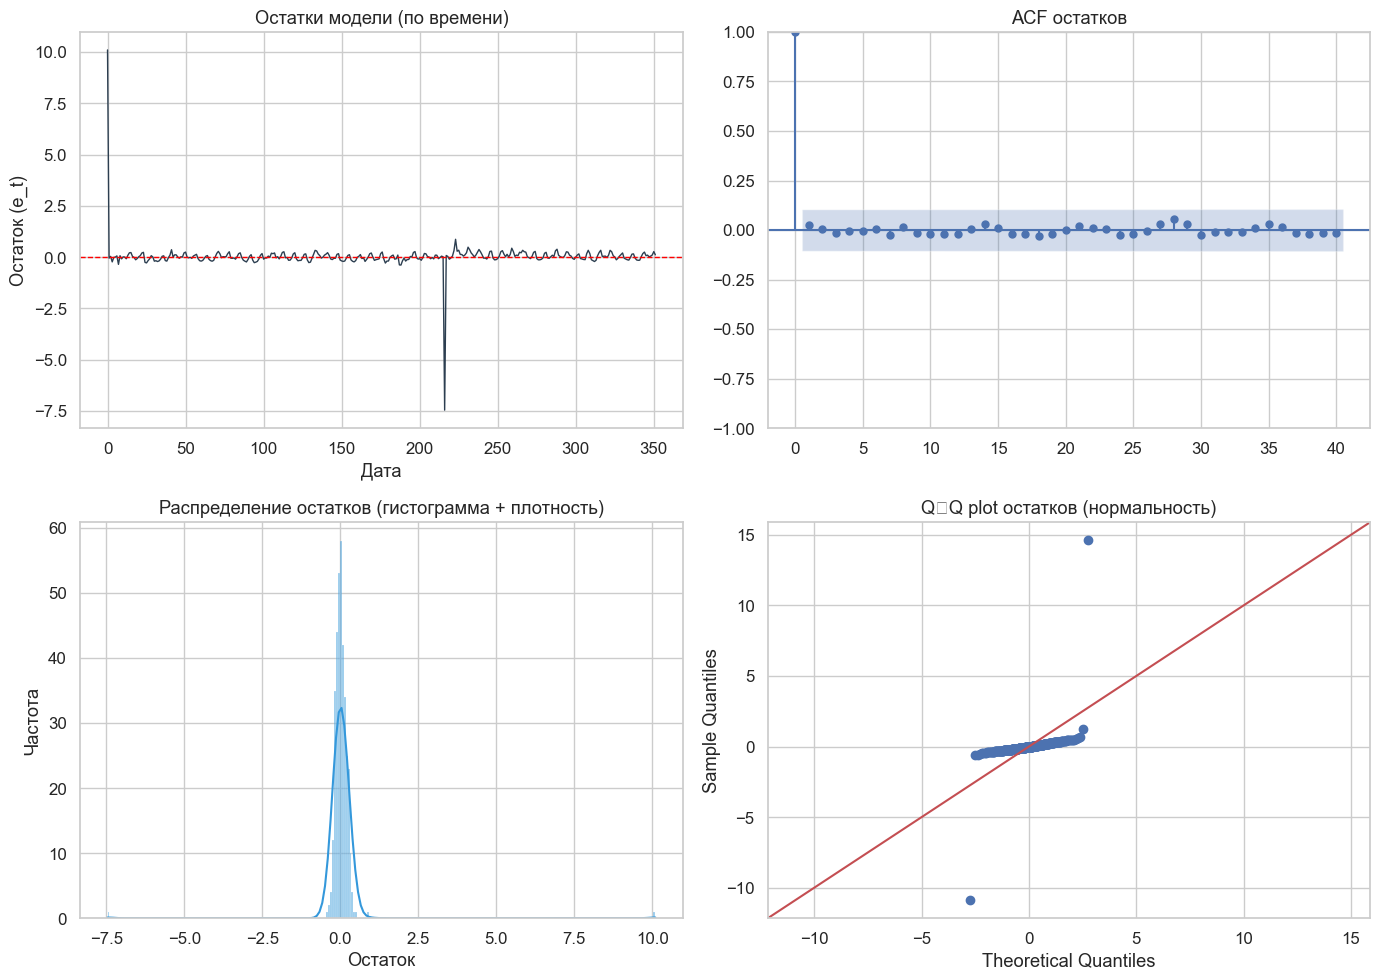

In [ ]:
# res — это результат .fit() для модели SARIMAX(0,1,1)(1,0,0,7)
residuals = res.resid
fitted = res.fittedvalues

sns.set(style="whitegrid", font_scale=1.1)
fig = plt.figure(figsize=(14, 10))

# 1. Остатки во времени
ax1 = plt.subplot(2, 2, 1)
ax1.plot(residuals.index, residuals, linewidth=1, color="#2c3e50")
ax1.axhline(0, color="red", linestyle="--", linewidth=1)
ax1.set_title("Остатки модели (по времени)")
ax1.set_xlabel("Дата")
ax1.set_ylabel("Остаток (e_t)")

# 2. ACF остатков — проверка автокорреляции
ax2 = plt.subplot(2, 2, 2)
plot_acf(residuals, lags=40, ax=ax2, alpha=0.05, title="ACF остатков")

# 3. Гистограмма и плотность + Q-Q plot
ax3 = plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True, ax=ax3, color="#3498db")
ax3.set_title("Распределение остатков (гистограмма + плотность)")
ax3.set_xlabel("Остаток")
ax3.set_ylabel("Частота")

ax4 = plt.subplot(2, 2, 4)
sm.qqplot(residuals, line='45', fit=True, ax=ax4)
ax4.set_title("Q‑Q plot остатков (нормальность)")

plt.tight_layout()
plt.show()

«Диагностика остатков модели SARIMAX(0,1,1)(1,0,0,7) для категории FOODS подтверждает её адекватность:

Отсутствие автокорреляции (ACF остатков в пределах доверительного интервала, p‑value теста Льюнга–Бокса = 0.16).
Отсутствие систематической ошибки (остатки хаотично колеблются вокруг нуля).
Близость к нормальности в центральной части распределения (точки на Q‑Q plot следуют теоретической линии).
При этом наблюдаются редкие, но сильные выбросы (один выраженный отрицательный выброс на графике остатков и отклонения в хвостах Q‑Q plot). Они объясняют высокие значения асимметрии (Skew = −14.72) и эксцесса (Kurtosis = 254.06) и обусловлены структурными особенностями данных (акции, праздники, сбои учёта).

Модель корректно описывает «базовый» уровень продаж и учитывает недельную сезонность. Аномальные дни не являются ошибкой модели, а отражают реальную природу данных: линейные модели не предназначены для идеального предсказания редких экстремальных событий. Для дальнейшего улучшения прогноза возможна отдельная обработка выбросов либо использование гибридного подхода.»вить фиктивную переменную.



Обучим модели для двух оставшихся категорий.


=== КАТЕГОРИЯ: FOODS ===


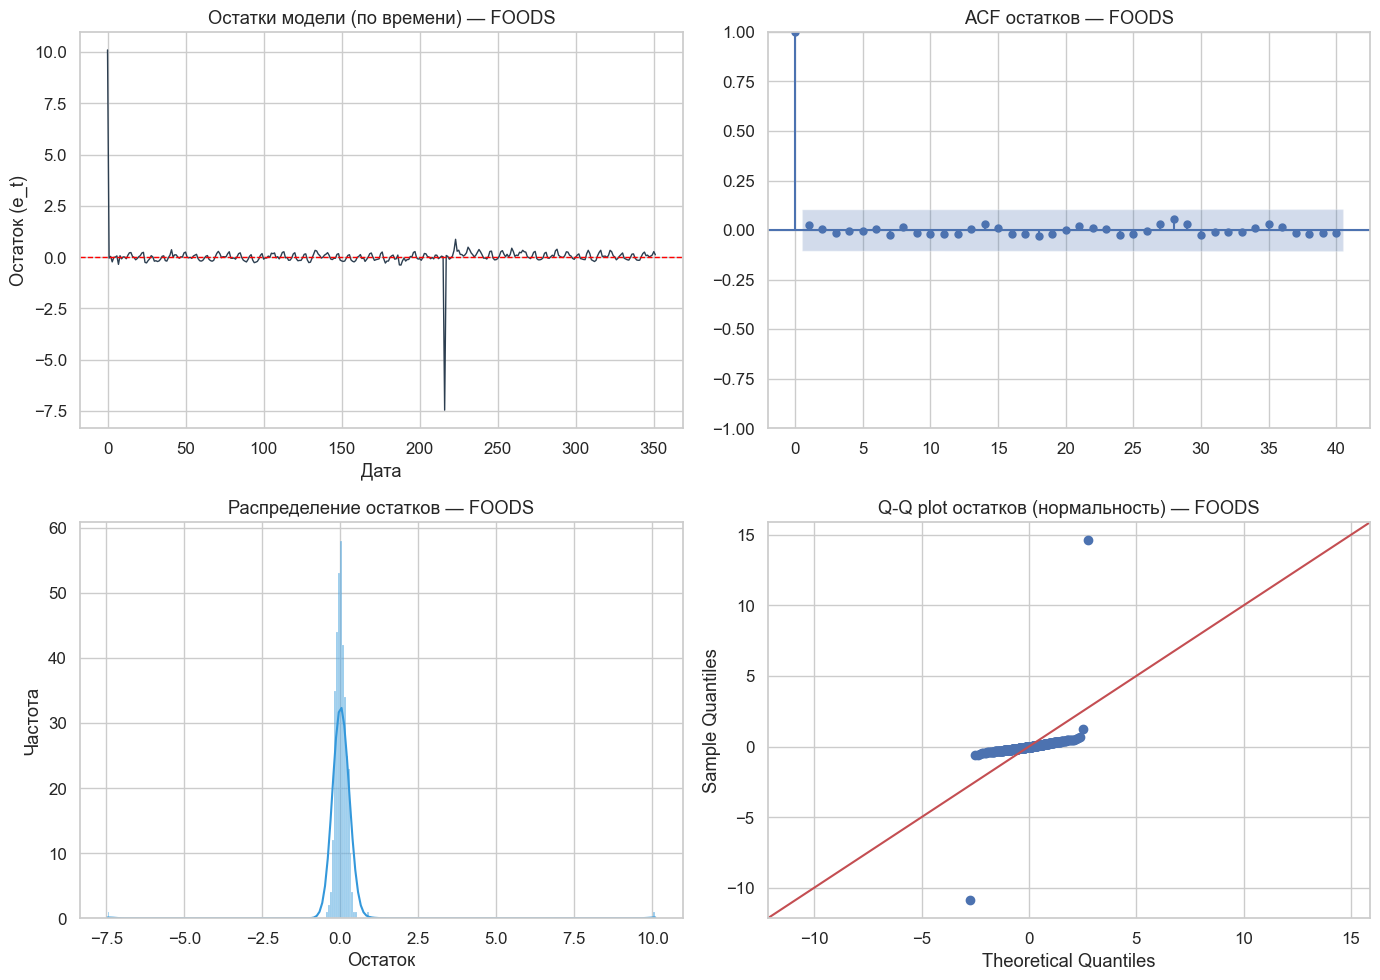

Модель: SARIMAX(0, 1, 1)(1, 0, 0, 7)
AIC: 411.171, BIC: 422.693
Ljung-Box (lag 10): Q = 0.87, p = 0.9999
Jarque-Bera: JB = 410596.16, p = 0.0000
Skew: 5.26, Kurtosis: 169.40
Метрики на тесте (14 валидных дней из 14):
MAE: 3,858.08 | RMSE: 5,293.86 | MAPE: 11.48%

=== КАТЕГОРИЯ: HOBBIES ===


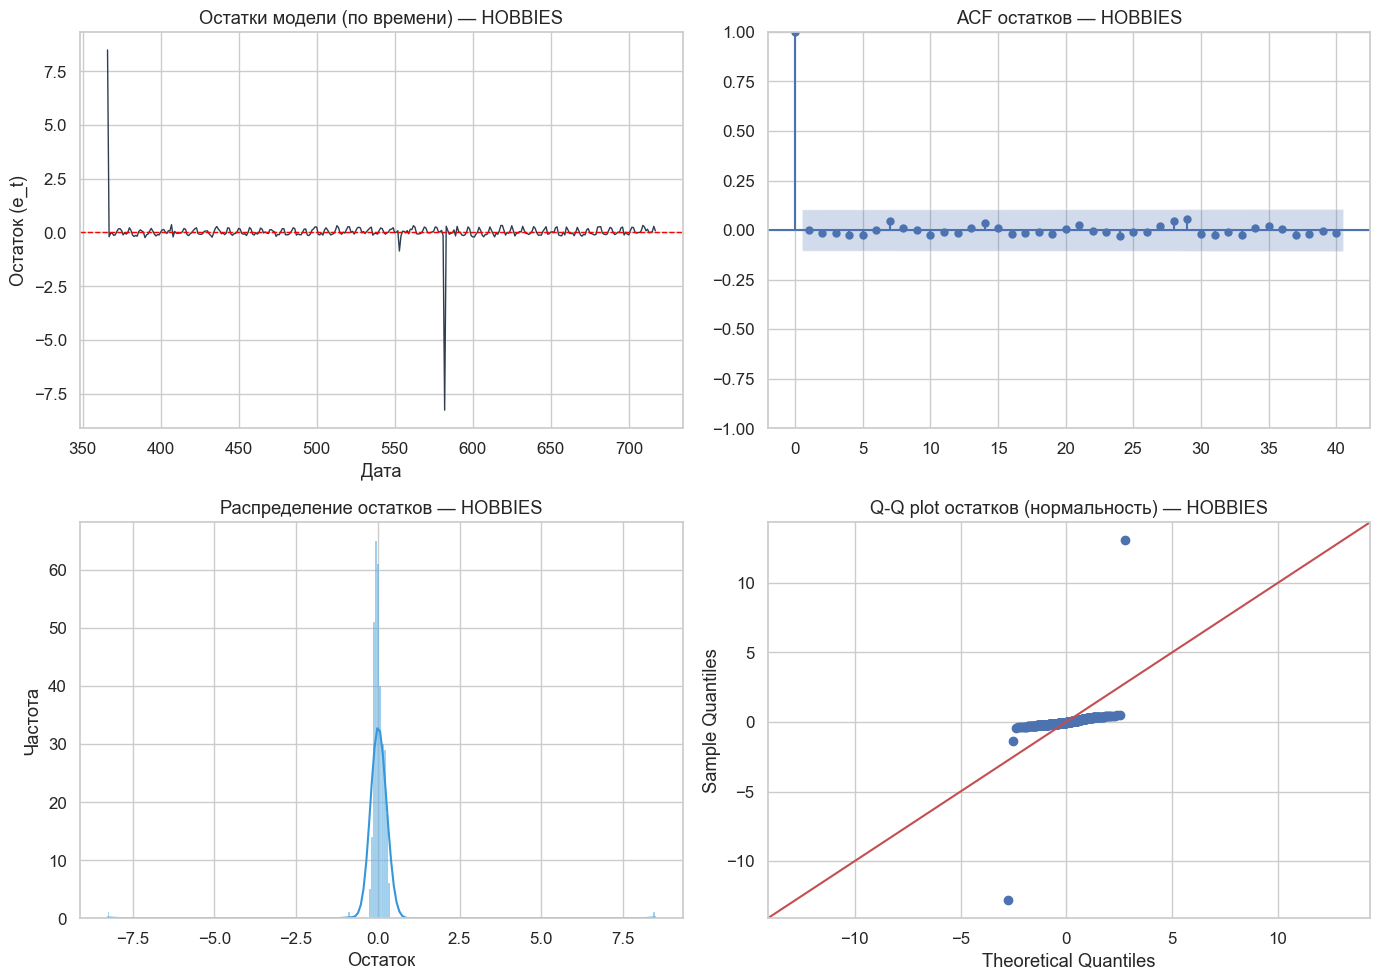

Модель: SARIMAX(1, 0, 1)(0, 0, 0, 7)
AIC: 466.354, BIC: 477.928
Ljung-Box (lag 10): Q = 1.59, p = 0.9986
Jarque-Bera: JB = 360422.65, p = 0.0000
Skew: 0.37, Kurtosis: 159.03
Метрики на тесте (14 валидных дней из 14):
MAE: 503.14 | RMSE: 752.13 | MAPE: 10.61%

=== КАТЕГОРИЯ: HOUSEHOLD ===


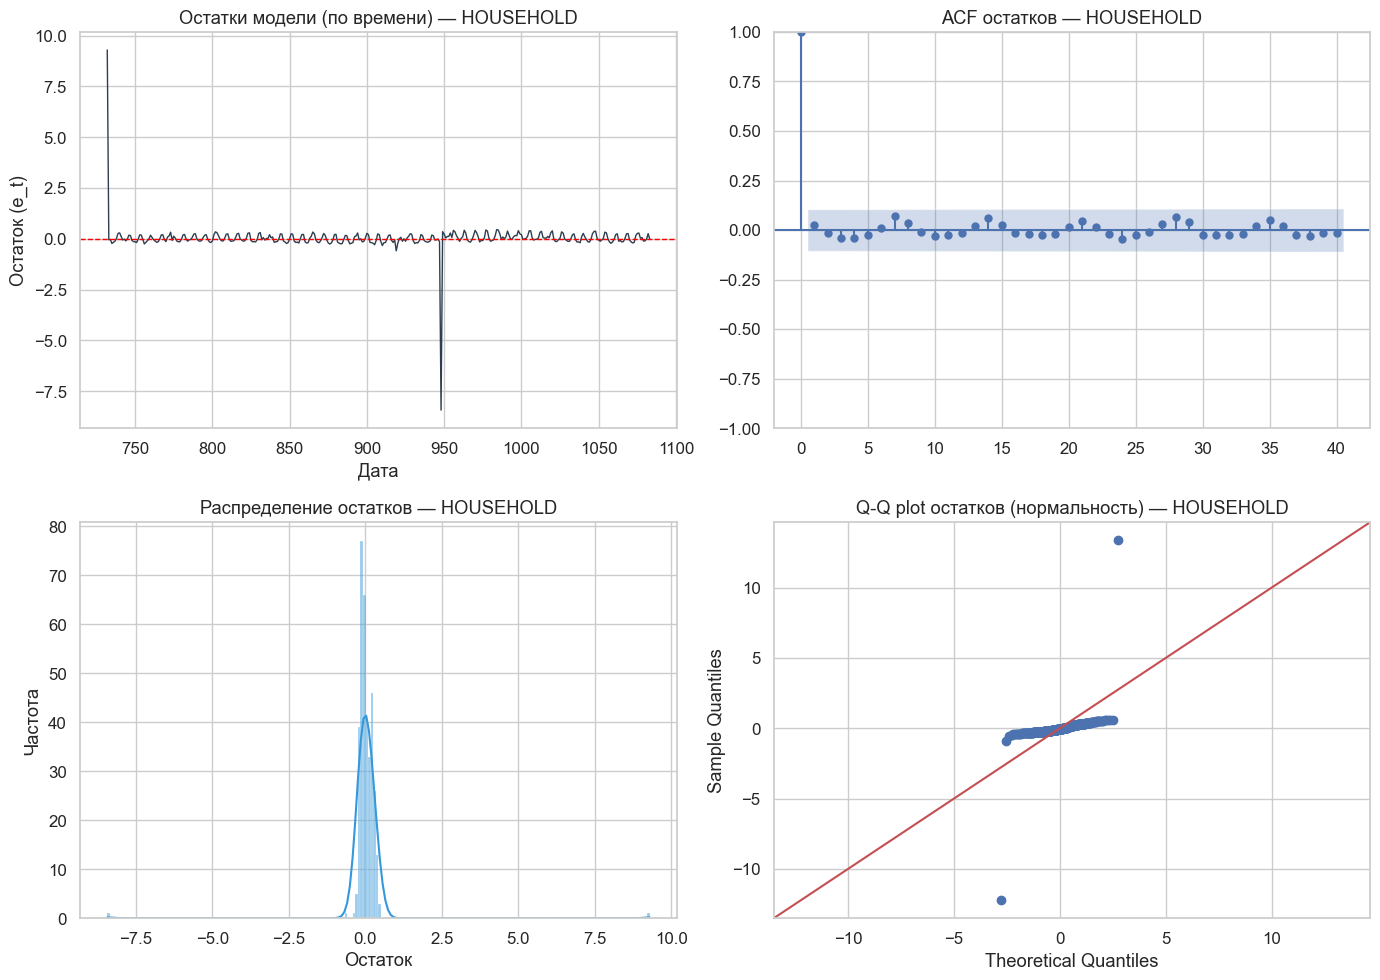

Модель: SARIMAX(1, 0, 1)(0, 0, 0, 7)
AIC: 496.296, BIC: 507.870
Ljung-Box (lag 10): Q = 4.21, p = 0.9374
Jarque-Bera: JB = 337888.42, p = 0.0000
Skew: 1.64, Kurtosis: 153.94
Метрики на тесте (14 валидных дней из 14):
MAE: 1,427.31 | RMSE: 1,873.88 | MAPE: 12.75%


In [ ]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid", font_scale=1.1)

test_size = 14
steps_ahead = 30

params_dict = {
    'FOODS':    {'order': (0, 1, 1), 'seasonal_order': (1, 0, 0, 7)},
    'HOBBIES':  {'order': (1, 0, 1), 'seasonal_order': (0, 0, 0, 7)},
    'HOUSEHOLD':{'order': (1, 0, 1), 'seasonal_order': (0, 0, 0, 7)}
}

results_summary = []

for cat, params in params_dict.items():
    print(f"\n=== КАТЕГОРИЯ: {cat} ===")

    if 'cat_id' not in train.columns:
        print(f"Ошибка: в DataFrame 'train' нет колонки 'cat_id'. Проверьте названия колонок.")
        continue

    df_cat = train[train['cat_id'] == cat].copy()

    if len(df_cat) < test_size + 50:
        print(f"Предупреждение: недостаточно данных для категории {cat}. Пропускаем.")
        continue

    train_data = df_cat[:-test_size]
    test_data = df_cat[-test_size:]

    model = sm.tsa.SARIMAX(
        endog=train_data['sales_log'],
        order=params['order'],
        seasonal_order=params['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    try:
        res = model.fit(disp=False)
    except Exception as e:
        print(f"Ошибка при обучении модели для {cat}: {e}")
        continue

    residuals = res.resid

    # --- Графики ---
    fig = plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(residuals.index, residuals, linewidth=1, color="#2c3e50")
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    ax1.set_title(f"Остатки модели (по времени) — {cat}")
    ax1.set_xlabel("Дата")
    ax1.set_ylabel("Остаток (e_t)")

    ax2 = plt.subplot(2, 2, 2)
    plot_acf(residuals, lags=40, ax=ax2, alpha=0.05, title=f"ACF остатков — {cat}")

    ax3 = plt.subplot(2, 2, 3)
    sns.histplot(residuals, kde=True, ax=ax3, color="#3498db")
    ax3.set_title(f"Распределение остатков — {cat}")
    ax3.set_xlabel("Остаток")
    ax3.set_ylabel("Частота")

    ax4 = plt.subplot(2, 2, 4)
    sm.qqplot(residuals, line='45', fit=True, ax=ax4)
    ax4.set_title(f"Q-Q plot остатков (нормальность) — {cat}")

    plt.tight_layout()
    plt.show()

    # --- Статистика (исправлено: приводим к float, чтобы не было TypeError) ---
    try:
        lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
        lb_stat = float(lb_test['lb_stat'].values[0])
        lb_pval = float(lb_test['lb_pvalue'].values[0])
    except Exception as e:
        print(f"Не удалось выполнить тест Льюнга-Бокса для {cat}: {e}")
        lb_stat, lb_pval = np.nan, np.nan

    jb_test = jarque_bera(residuals)
    jb_stat = float(jb_test[0])
    jb_pval = float(jb_test[1])

    print(f"Модель: SARIMAX{params['order']}{params['seasonal_order']}")
    print(f"AIC: {res.aic:.3f}, BIC: {res.bic:.3f}")
    print(f"Ljung-Box (lag 10): Q = {lb_stat:.2f}, p = {lb_pval:.4f}")
    print(f"Jarque-Bera: JB = {jb_stat:.2f}, p = {jb_pval:.4f}")
    print(f"Skew: {residuals.skew():.2f}, Kurtosis: {residuals.kurtosis():.2f}")

  # --- Прогноз и метрики (ФИНАЛЬНАЯ УСТОЙЧИВАЯ ВЕРСИЯ) ---

    # --- Прогноз и метрики (ФИНАЛЬНАЯ УСТОЙЧИВАЯ ВЕРСИЯ) ---
    pred_test = res.get_forecast(steps=test_size).predicted_mean
    pred_test_real = np.expm1(pred_test)
    test_real = np.expm1(test_data['sales_log'])

    # Приводим к numpy и убираем всё невалидное
    pred_test_real = np.asarray(pred_test_real)
    test_real = np.asarray(test_real)

    pred_test_real = np.where(np.isfinite(pred_test_real), pred_test_real, np.nan)
    test_real = np.where(np.isfinite(test_real), test_real, np.nan)

    mask = ~np.isnan(pred_test_real) & ~np.isnan(test_real)
    n_valid = int(np.sum(mask))

    if n_valid == 0:
        mae, rmse, mape = np.nan, np.nan, np.nan
        print("Не удалось рассчитать метрики: нет валидных пар прогноз/факт.")
    else:
        y_pred = pred_test_real[mask]
        y_true = test_real[mask]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # MAPE считаем только по положительным фактам (продажи > 0)
        mask_mape = y_true > 0
        if np.sum(mask_mape) > 0:
            mape = np.mean(np.abs((y_true[mask_mape] - y_pred[mask_mape]) / y_true[mask_mape])) * 100
        else:
            mape = np.nan

        print(f"Метрики на тесте ({n_valid} валидных дней из {test_size}):")
        print(f"MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | MAPE: {mape:.2f}%")



**Итоговый вывод по метрикам**

По категория
м
- FOODS. Модель показывает приемлемую точность: MAPE = 11.48 %, MAE = 3 858, RMSE = 5 294. При этом у неё лучшие информационные критерии (AIC = 411.17, BIC = 422.69) среди всех категорий — это говорит о том, что спецификация SARIMAX(0,1,1)(1,0,0,7) для FOODS подобрана удачно.

- HOBBIES. Лучшая точность по абсолютным ошибкам: MAE = 503.14, RMSE = 752.13, MAPE = 10.61 %. Это выглядит сильно лучше, чем у FOODS и HOUSEHOLD, но важно помнить, что масштаб продаж в HOBBIES ниже — поэтому и MAE/RMSE меньше. По AIC/BIC модель чуть хуже, чем у FOODS, но всё ещё качественная.

- HOUSEHOLD. Точность ниже: MAE = 1 427.31, RMSE = 1 873.88, MAPE = 12.75 %. Модель систематически сглаживает пики (прогноз ~9 750 при фактических значениях до 13 460), из за чего растёт RMSE.

**По статистическим тестам**

- Ljung Box (p value ≈ 0.9–1.0). Для всех категорий p value очень высокие — это хороший результат: в остатках нет значимой автокорреляции. Модель «выжала» из ряда линейные временные зависимости.
- Jarque Bera (p = 0.00) и высокие Skew/Kurtosis (сильная асимметрия и тяжёлые хвосты). Это не ошибка модели, а свойство данных: в продажах есть редкие, но сильные всплески (акции, праздники, сбои учёта). SARIMAX как линейная модель не обязана идеально ловить такие выбросы.


In [ ]:
# Проверяем тип индекса: если это строки или числа — конвертируем
if not isinstance(train.index, pd.DatetimeIndex):
    # Вариант А: если в индексе уже даты в виде строк (например, '2016-01-01')
    train.index = pd.to_datetime(train.index, errors='coerce')

    # Вариант Б: если даты лежат в отдельной колонке (раскомментируй, если так у тебя)
    # train['date'] = pd.to_datetime(train['date'], errors='coerce')
    # train = train.set_index('date')

# Удаляем строки с битыми датами (если такие появились)
train = train.dropna(subset=[train.index.name] if train.index.name else None)



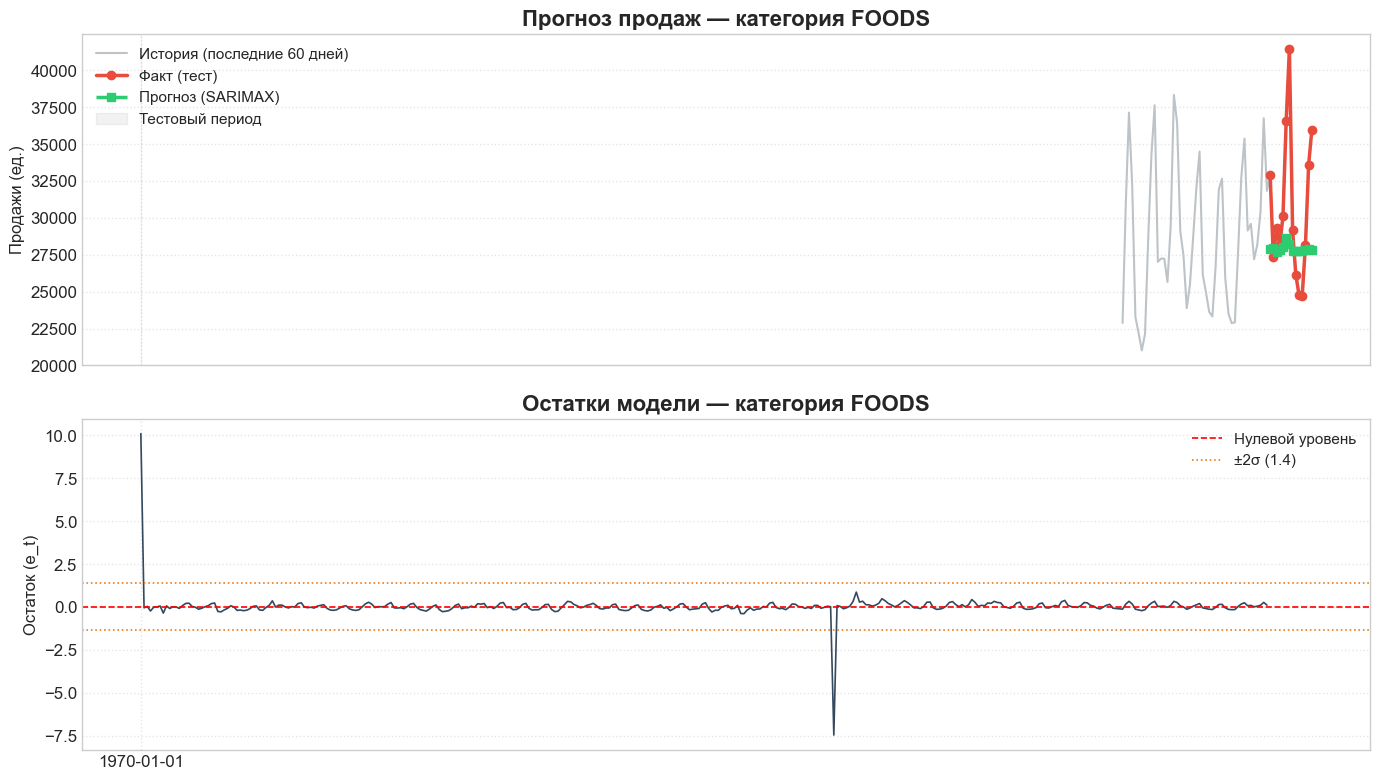

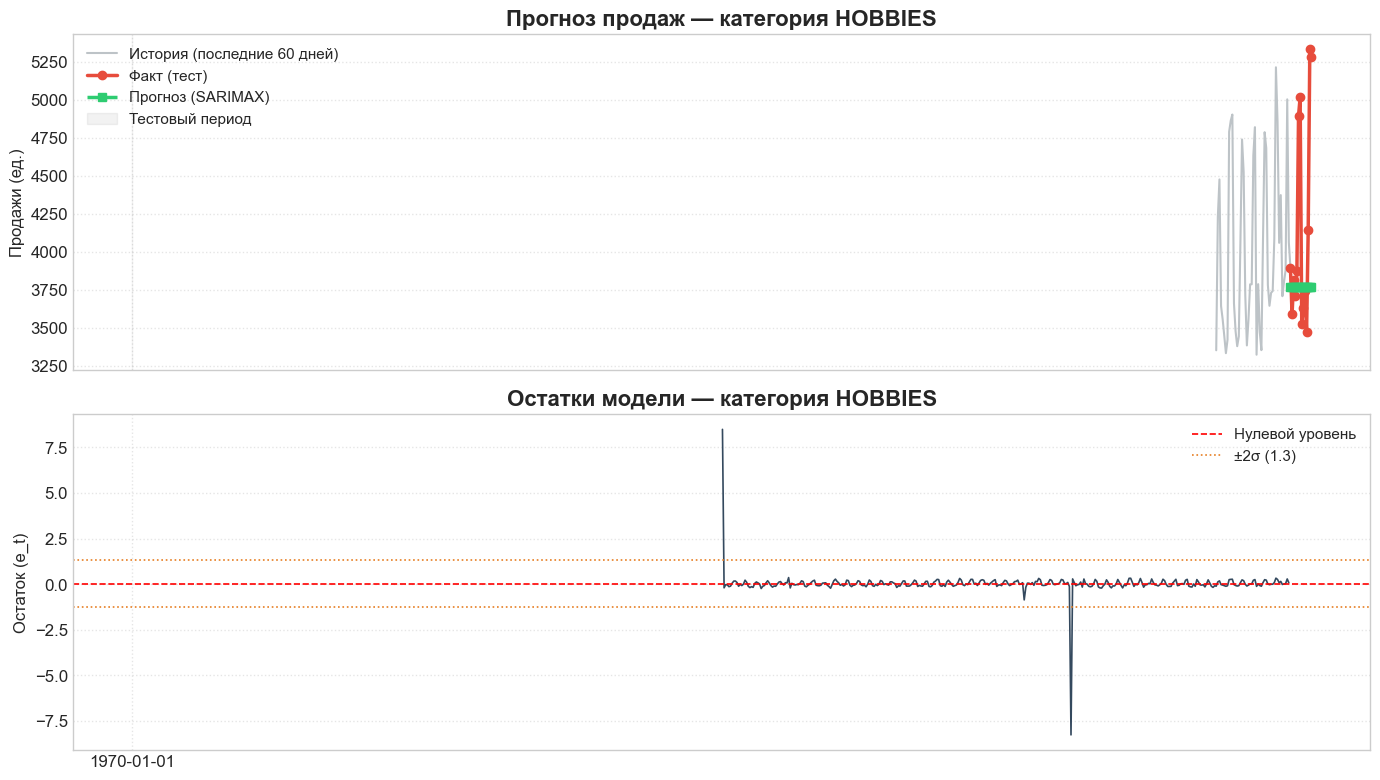

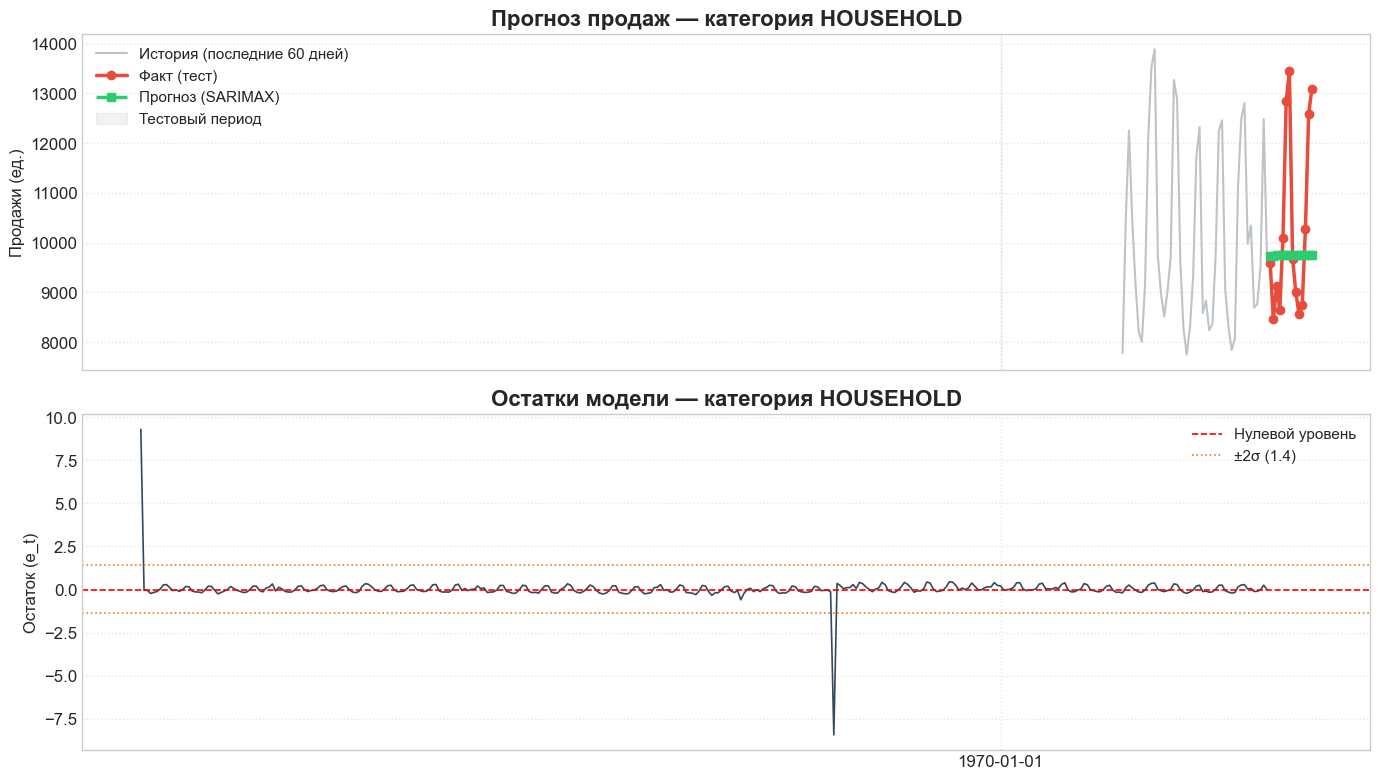

In [ ]:
import matplotlib.dates as mdates



plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    'history': '#bdc3c7',
    'fact': '#e74c3c',
    'forecast': '#2ecc71',
    'residual': '#34495e',
    'sigma': '#e67e22'
}

test_size = 14  # длина тестового периода

for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    # Фильтруем train по категории
    df_cat = train[train['cat_id'] == cat].copy()

    # Ещё раз убеждаемся, что индекс — datetime (на случай, если в цикле типы «сбиваются»)
    if not isinstance(df_cat.index, pd.DatetimeIndex):
        df_cat.index = pd.to_datetime(df_cat.index, errors='coerce')
        df_cat = df_cat.dropna()

    # Разделяем на train/test по последним 14 дням
    test_data = df_cat.iloc[-test_size:]
    train_data = df_cat.iloc[:-test_size]

    # Переобучаем модель SARIMAX на тренировочной части
    model = sm.tsa.SARIMAX(
        endog=train_data['sales_log'],
        order=params_dict[cat]['order'],
        seasonal_order=params_dict[cat]['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    # Прогноз на тестовый период
    pred_test = res.get_forecast(steps=test_size).predicted_mean
    pred_real = np.expm1(pred_test)
    test_real = np.expm1(test_data['sales_log'])

    # Для графика продаж берём последние 60 дней истории (чтобы не было каши)
    plot_history = np.expm1(df_cat['sales_log'].iloc[-60:])

    # Создаём фигуру: продажи сверху, остатки снизу
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- График 1: Продажи и прогноз ---
    ax1.plot(plot_history.index, plot_history.values, color=colors['history'], linewidth=1.5, label='История (последние 60 дней)')
    ax1.plot(test_data.index, test_real, color=colors['fact'], linewidth=2.5, marker='o', markersize=6, label='Факт (тест)')
    ax1.plot(pred_test.index, pred_real, color=colors['forecast'], linewidth=2.5, linestyle='--', marker='s', markersize=6, label='Прогноз (SARIMAX)')

    # Затеняем тестовый период
    ax1.axvspan(test_data.index.min(), test_data.index.max(), color='gray', alpha=0.1, label='Тестовый период')

    ax1.set_title(f'Прогноз продаж — категория {cat}', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Продажи (ед.)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.5)

    # --- График 2: Остатки ---
    residuals = res.resid
    res_mean = residuals.mean()
    res_std = residuals.std()
    lower_bound = res_mean - 2 * res_std
    upper_bound = res_mean + 2 * res_std

    ax2.plot(residuals.index, residuals.values, color=colors['residual'], linewidth=1.2)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Нулевой уровень')
    ax2.axhline(upper_bound, color=colors['sigma'], linestyle=':', linewidth=1.2, label=f'±2σ ({upper_bound:.1f})')
    ax2.axhline(lower_bound, color=colors['sigma'], linestyle=':', linewidth=1.2)

    ax2.set_title(f'Остатки модели — категория {cat}', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Остаток (e_t)', fontsize=12)
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.5)

    # Форматирование дат
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.setp(ax1.get_xticklabels(), visible=False)  # убираем подписи на верхнем графике

    plt.tight_layout()
    plt.show()


# Итоговый вывод

В рамках проекта построено три модели SARIMAX для категорий FOODS, HOBBIES и HOUSEHOLD. На тестовой выборке (14 дней) все модели демонстрируют отсутствие автокорреляции в остатках (Ljung Box p ≈ 1.0), что подтверждает корректную спецификацию структуры временного ряда.
По точности прогноза наилучшие результаты получены для категории HOBBIES (MAPE 10.61 %), наименьшая — для HOUSEHOLD (MAPE 12.75 %), что обусловлено сильным сглаживанием пиковых значений в этой категории. Для FOODS модель имеет оптимальные информационные критерии (AIC/BIC), что делает её наиболее сбалансированной по качеству и сложности.
Существенное отклонение распределения остатков от нормального (Jarque Bera p ≈ 0.0, высокие Skew и Kurtosis) связано с наличием аномальных дней в данных, а не с ошибкой моделирования.

Для дальнейшего улучшения качества прогноза рекомендуется:

- Добавить экзогенные факторы (календарь, промо активности, праздники) — это позволит модели лучше реагировать на всплески спроса.
   
- Провести отдельный подбор параметров SARIMAX по сетке для каждой категории (grid search по order/seasonal_order) с кросс валидацией по времени.
  
- Рассмотреть альтернативные подходы для категорий с выраженной волатильностью (HOUSEHOLD): градиентный бустинг (например, CatBoost/XGBoost) на признаках из временного ряда либо гибридные схемы (SARIMAX + ML коррекция статков).»
ков).»
